<a href="https://colab.research.google.com/github/asegura4488/FisicaA/blob/main/Semana7/TrayectoriaCarga3D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

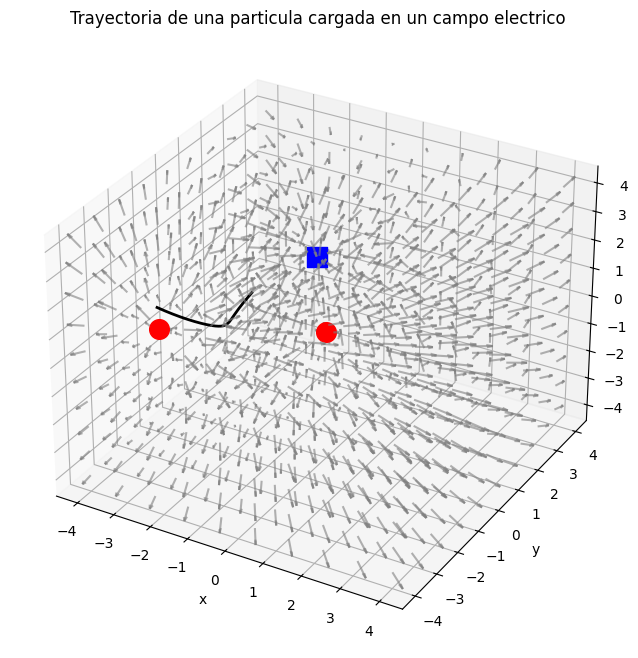

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from mpl_toolkits.mplot3d import Axes3D

# =====================================================
# MOVIMIENTO DE UNA CARGA EN UN CAMPO ELECTRICO 3D
# METODO DE EULER + VISUALIZACION DEL CAMPO
# =====================================================

# -----------------------------
# Cargas fijas
# Cada carga: [x0, y0, z0, q]
# -----------------------------
cargas = np.array([
    [0.0, 0.0, 0.0, 1.0],
    [-2.0, 3.0, 0.0, -1.0],
    [-2.0, -4.0,  +2.0, +1.0]
])

# -----------------------------
# Parametros de la particula movil
# -----------------------------
q_test = 1.0
m = 1.0

# Posicion y velocidad inicial
r = np.array([-4.0, -1.0, 0.0], dtype=float)
v = np.array([0.5, -0.1, 0.0], dtype=float)

dt = 0.01
N = 1000

trayectoria = np.zeros((N,3))

# -----------------------------
# Funcion para calcular campo
# -----------------------------
def campo_en_punto(r, cargas):

    Ex = 0.0
    Ey = 0.0
    Ez = 0.0

    x, y, z = r

    for carga in cargas:

        x0, y0, z0, q = carga

        dx = x - x0
        dy = y - y0
        dz = z - z0

        r2 = dx**2 + dy**2 + dz**2
        dist = np.sqrt(r2)

        if dist < 1e-6:
            continue

        factor = q / dist**3

        Ex += factor * dx
        Ey += factor * dy
        Ez += factor * dz

    return np.array([Ex, Ey, Ez])


# -----------------------------
# Integracion con Euler
# -----------------------------
for n in range(N):

    trayectoria[n] = r

    E = campo_en_punto(r, cargas)

    v = v + (q_test/m) * E * dt
    r = r + v * dt


# =====================================================
# VISUALIZACION
# =====================================================

fig = plt.figure(figsize=(9,8))
ax = fig.add_subplot(111, projection='3d')

# -----------------------------
# Trayectoria de la particula
# -----------------------------
ax.plot(trayectoria[:,0],
        trayectoria[:,1],
        trayectoria[:,2],
        color='black',
        linewidth=2,
        label='Trayectoria')


# -----------------------------
# Dibujar cargas
# -----------------------------
for carga in cargas:

    x0, y0, z0, q = carga

    if q > 0:
        ax.scatter(x0, y0, z0, s=200, color='red')
    else:
        ax.scatter(x0, y0, z0, s=200, color='blue', marker='s')


# -----------------------------
# Dibujar algunos vectores de campo
# -----------------------------
grid = np.linspace(-4,4,10)

for x in grid:
    for y in grid:
        for z in grid:

            r_point = np.array([x,y,z])
            E = campo_en_punto(r_point, cargas)

            ax.quiver(x, y, z,
                      E[0], E[1], E[2],
                      length=0.5,
                      normalize=True,
                      color='gray',
                      alpha=0.6)


# -----------------------------
# Etiquetas
# -----------------------------
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax.set_title("Trayectoria de una particula cargada en un campo electrico")

plt.savefig("Trayectoria_carga_3D.pdf",
            dpi=300,
            bbox_inches="tight")

plt.show()

files.download("Trayectoria_carga_3D.pdf")